In [2]:
import numpy as np
import math
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
%matplotlib inline


In [3]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

GPU: Tesla T4 is available.
Using device: cuda


In [4]:
data1 = np.load('/content/kotak3_bener.npz')
data2 = np.load('/content/kotak15_bener_lebar.npz')
data3 = np.load('/content/kotak1_bener.npz')



In [5]:
psi_awal1  = data1['psi_awal']
psi_akhir1 = data1['psi_akhir']
potensial1 = data1['potensial']

psi_awal2  = data2['psi_awal']
psi_akhir2 = data2['psi_akhir']
potensial2 = data2['potensial']

psi_awal3  = data3['psi_awal']
psi_akhir3 = data3['psi_akhir']
potensial3 = data3['potensial']


psi_awal_all = np.concatenate([psi_awal1, psi_awal2, psi_awal3], axis=0)
potensial_all = np.concatenate([potensial1, potensial2, potensial3], axis=0)
psi_akhir_all = np.concatenate([psi_akhir1, psi_akhir2, psi_akhir3], axis=0)  # ini sudah benar
#dataset input dan output
X = np.stack([psi_awal_all, potensial_all], axis=-1)
y = psi_akhir_all


In [6]:
# Normlaisasi output y
y_max = np.max(abs(y), axis=-1, keepdims=True)
y_norm  = y / y_max
y_norm = y_norm[:,:,np.newaxis]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_norm, test_size=0.2, random_state=42
)

#PyTorch hanya bisa bekerja dengan Tensor, bukan NumPy array
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("X_train:", X_train_tensor.shape)  # harusnya (N, 101, 1)
print("y_train:", y_train_tensor.shape)  # harusnya (N, 101)
print(X_train_tensor.shape)
print(y_train_tensor.shape)

X_train: torch.Size([12000, 101, 2])
y_train: torch.Size([12000, 101, 1])
torch.Size([12000, 101, 2])
torch.Size([12000, 101, 1])


=== DATA 2 ===
X2_train : torch.Size([4000, 101, 2])
y2_train : torch.Size([4000, 101, 1])
X2_test  : torch.Size([1000, 101, 2])
y2_test  : torch.Size([1000, 101, 1])


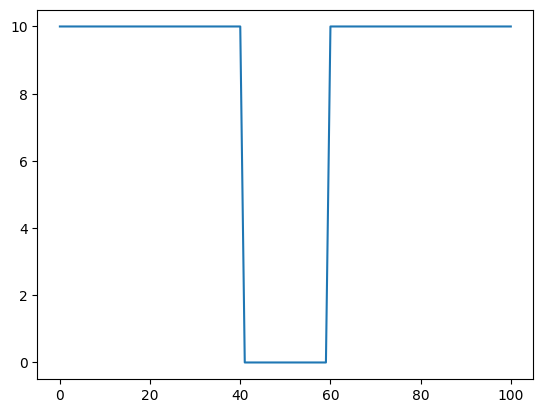

In [8]:
# ==========================
# INPUT DAN OUTPUT DATA 2
# ==========================
X2 = np.stack([psi_awal1, potensial1], axis=-1)
y2 = psi_akhir2

# Normalisasi output
# Terapkan ke input DAN output
y_max2 = np.max(abs(y2), axis=-1, keepdims=True)
y_norm2  = y2 / y_max2
y_norm2 = y_norm2[:,:,np.newaxis]


# TRAIN TEST SPLIT DATA 2
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y_norm2,test_size=0.2,random_state=42)

# NUMPY -> TENSOR
X2_train_tensor = torch.tensor(X2_train, dtype=torch.float32).to(device)
y2_train_tensor = torch.tensor(y2_train, dtype=torch.float32).to(device)
X2_test_tensor = torch.tensor(X2_test, dtype=torch.float32).to(device)
y2_test_tensor = torch.tensor(y2_test, dtype=torch.float32).to(device)

train_dataset2 = TensorDataset(X2_train_tensor,y2_train_tensor)
test_dataset2 = TensorDataset(X2_test_tensor,y2_test_tensor)
train_loader2 = DataLoader(train_dataset2,batch_size=64,shuffle=True)
test_loader2 = DataLoader(test_dataset2,batch_size=64,shuffle=False)

print("=== DATA 2 ===")
print("X2_train :", X2_train_tensor.shape)
print("y2_train :", y2_train_tensor.shape)
print("X2_test  :", X2_test_tensor.shape)
print("y2_test  :", y2_test_tensor.shape)
plt.plot(potensial1[0,:])

=== DATA 3 ===
X3_train : torch.Size([4000, 101, 2])
y3_train : torch.Size([4000, 101, 1])
X3_test  : torch.Size([1000, 101, 2])
y3_test  : torch.Size([1000, 101, 1])


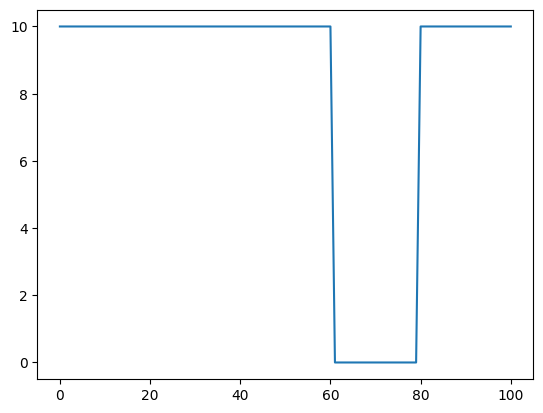

In [9]:
# ==========================
# INPUT DAN OUTPUT DATA 3
# ==========================
X3 = np.stack([psi_awal3, potensial3], axis=-1)
y3 = psi_akhir3

y_max3 = np.max(abs(y3), axis=-1, keepdims=True)
y_norm3  = y3 / y_max3
y_norm3 = y_norm3[:,:,np.newaxis]

# TRAIN TEST SPLIT DATA 3
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y_norm3,test_size=0.2,random_state=42)

# NUMPY -> TENSOR
X3_train_tensor = torch.tensor(X3_train, dtype=torch.float32).to(device)
y3_train_tensor = torch.tensor(y3_train, dtype=torch.float32).to(device)
X3_test_tensor = torch.tensor(X3_test, dtype=torch.float32).to(device)
y3_test_tensor = torch.tensor(y3_test, dtype=torch.float32).to(device)

train_dataset3 = TensorDataset(X3_train_tensor,y3_train_tensor)
test_dataset3 = TensorDataset(X3_test_tensor,y3_test_tensor)
train_loader3 = DataLoader(train_dataset3,batch_size=64,shuffle=True)
test_loader3 = DataLoader(test_dataset3,batch_size=64,shuffle=False)

print("=== DATA 3 ===")
print("X3_train :", X3_train_tensor.shape)
print("y3_train :", y3_train_tensor.shape)
print("X3_test  :", X3_test_tensor.shape)
print("y3_test  :", y3_test_tensor.shape)
plt.plot(potensial3[0,:])

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 256, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(100000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class DualStreamQuantumTransformer(nn.Module):

    def __init__(
        self,
        seq_len: int = 101,
        d_model: int = 64,
        nhead: int = 8,
        num_self_layers: int = 4,
        num_fusion_layers: int = 1,
        dim_feedforward: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()
        assert d_model % nhead == 0, f"d_model ({d_model}) harus habis dibagi nhead ({nhead})"

        # Proyeksi terpisah: masing-masing channel (psi, V) -> d_model
        self.psi_proj = nn.Linear(1, d_model)
        self.v_proj   = nn.Linear(1, d_model)

        # Positional encoding dipakai untuk kedua stream (boleh juga dua instance terpisah)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len + 10, dropout=dropout)

        # Self-attention encoder terpisah untuk psi dan untuk V
        self_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.psi_encoder = nn.TransformerEncoder(self_layer, num_layers=num_self_layers)

        v_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.v_encoder = nn.TransformerEncoder(v_layer, num_layers=num_self_layers)

        # Cross-attention: psi (query) menyerap informasi dari V (key/value)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True
        )
        self.cross_norm = nn.LayerNorm(d_model)

        # Encoder lanjutan setelah fusion, untuk merapikan representasi gabungan
        fusion_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.fusion_encoder = nn.TransformerEncoder(fusion_layer, num_layers=num_fusion_layers)

        # Output head: sama seperti model asli
        self.output_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (batch, seq_len, 2) -> pisahkan channel psi dan V
        psi_raw = x[..., 0:1]   # (batch, seq_len, 1)
        v_raw   = x[..., 1:2]   # (batch, seq_len, 1)

        # Proyeksi + positional encoding, masing-masing stream independen
        psi = self.pos_enc(self.psi_proj(psi_raw))   # (batch, seq_len, d_model)
        v   = self.pos_enc(self.v_proj(v_raw))        # (batch, seq_len, d_model)

        # Self-attention internal masing-masing stream
        psi = self.psi_encoder(psi)
        v   = self.v_encoder(v)

        # Cross-attention: psi bertanya ke V, "seberapa besar pengaruhmu di sini?"
        fused, attn_weights = self.cross_attn(query=psi, key=v, value=v)
        fused = self.cross_norm(fused + psi)  # residual connection

        # Refine representasi gabungan
        fused = self.fusion_encoder(fused)

        out = self.output_head(fused)  # (batch, seq_len, 1)
        return out





In [ ]:
import copy
import torch
import torch.nn as nn

def run(d_model=64,nhead=8,n_layers=4,dim_feedforward=512,lr=1e-3,weight_decay=1e-5,step_size=20,gamma=0.5,n_epochs=100,num_fusion_layer=1):

    model = DualStreamQuantumTransformer(
        d_model=d_model,
        nhead=nhead,
        num_self_layers=n_layers,
        num_fusion_layers=num_fusion_layer,
        dim_feedforward=dim_feedforward,
        dropout=0.1,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=step_size,
        gamma=gamma,
    )

    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    best_loss = float("inf")
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(n_epochs):

        model.train()
        total_train_loss = 0

        for X_train_batch, y_train_batch in train_loader:

            X_train_batch = X_train_batch.to(device)
            y_train_batch = y_train_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(X_train_batch)

            loss = criterion(y_pred, y_train_batch)

            loss.backward()

            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        train_losses.append(avg_train_loss)

        model.eval()

        total_test_loss = 0

        with torch.no_grad():

            for X_test_batch, y_test_batch in test_loader:

                X_test_batch = X_test_batch.to(device)
                y_test_batch = y_test_batch.to(device)

                y_pred = model(X_test_batch)

                loss = criterion(y_pred, y_test_batch)

                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_loader)

        test_losses.append(avg_test_loss)


        if avg_test_loss < best_loss:
            best_loss = avg_test_loss
            best_model = copy.deepcopy(model.state_dict())

        scheduler.step()


    model.load_state_dict(best_model)

    return best_loss, model, train_losses, test_losses

In [ ]:
least_val_loss = float("inf")
least_loss_model = None
best_train_losses = None
best_test_losses = None
best_hyperparams = None


d_model_list = [32, 64]
n_head_list = [8]
n_layers_list = [2, 4]
lr_list = [1e-3]
step_size_list = [10, 15]
d_ffn_list = [64]
n_fusion_layer_list = [1]

total = (
    len(d_model_list)
    * len(n_head_list)
    * len(n_layers_list)
    * len(lr_list)
    * len(step_size_list)
    * len(d_ffn_list)
    *len(n_fusion_layer_list)
)

print(f"→ Total kombinasi: {total} hyperparameter\n")

counter = 0

for d_model in d_model_list:
    for n_head in n_head_list:
        for n_layers in n_layers_list:
            for lr in lr_list:
                for step_size in step_size_list:
                    for num_fusion_layer in n_fusion_layer_list:

                        counter += 1

                        print(
                            f"[{counter}/{total}] "
                            f"d_model={d_model}, "
                            f"n_head={n_head}, "
                            f"n_layers={n_layers}, "
                            f"n_fusion_layer={num_fusion_layer}, "
                            f"d_ff={d_model*4}, "
                            f"lr={lr}"
                        )

                        val_loss, model, train_losses, test_losses = run(
                            d_model=d_model,
                            nhead=n_head,
                            n_layers=n_layers,
                            num_fusion_layer=num_fusion_layer,
                            lr=lr,
                            weight_decay=1e-5,
                            step_size=step_size,
                            dim_feedforward=d_model*4,
                            gamma=0.5,
                            n_epochs=100,
                        )
                        print(f"Validasion loss : {val_loss:.6f}")

                        if val_loss < least_val_loss:
                            least_val_loss = val_loss
                            least_loss_model = model
                            best_train_losses = train_losses
                            best_test_losses = test_losses

                            best_hyperparams = {
                                "d_model": d_model,
                                "n_head": n_head,
                                "n_layers": n_layers,
                                "n_fusion_layer":num_fusion_layer,
                                "lr": lr,
                                "step_size": step_size,
                                "dim_feedforward": d_model*4,
                            }

                            print("\n===== NEW BEST MODEL =====")
                            print(best_hyperparams)
                            print(f"Validation Loss = {least_val_loss:.6f}\n")

print("\n========== GRID SEARCH FINISHED ==========")
print("Best Hyperparameters:")
print(best_hyperparams)
print(f"Best Validation Loss = {least_val_loss:.6f}")

→ Total kombinasi: 8 hyperparameter

[1/8] d_model=32, n_head=8, n_layers=2, n_fusion_layer=1, d_ff=128, lr=0.001
Validasion loss : 0.005699

===== NEW BEST MODEL =====
{'d_model': 32, 'n_head': 8, 'n_layers': 2, 'n_fusion_layer': 1, 'lr': 0.001, 'step_size': 10, 'dim_feedforward': 128}
Validation Loss = 0.005699

[2/8] d_model=32, n_head=8, n_layers=2, n_fusion_layer=1, d_ff=128, lr=0.001
Validasion loss : 0.000312

===== NEW BEST MODEL =====
{'d_model': 32, 'n_head': 8, 'n_layers': 2, 'n_fusion_layer': 1, 'lr': 0.001, 'step_size': 15, 'dim_feedforward': 128}
Validation Loss = 0.000312

[3/8] d_model=32, n_head=8, n_layers=4, n_fusion_layer=1, d_ff=128, lr=0.001
Validasion loss : 0.000304

===== NEW BEST MODEL =====
{'d_model': 32, 'n_head': 8, 'n_layers': 4, 'n_fusion_layer': 1, 'lr': 0.001, 'step_size': 10, 'dim_feedforward': 128}
Validation Loss = 0.000304

[4/8] d_model=32, n_head=8, n_layers=4, n_fusion_layer=1, d_ff=128, lr=0.001
Validasion loss : 0.000342
[5/8] d_model=64, n_he

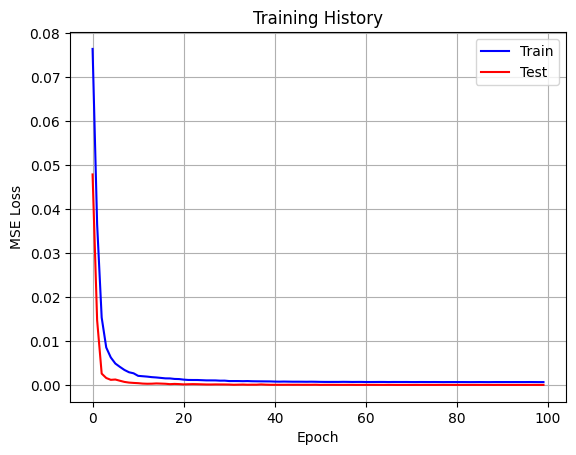

In [ ]:
import matplotlib.pyplot as plt

plt.plot(best_train_losses, label='Train', color='blue')
plt.plot(best_test_losses, label='Test', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
import time

X_test_list, y_true_list, y_pred_list = [], [], []

model.eval()

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.no_grad():
    for X_batch, y_batch in test_loader2:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        X_test_list.append(X_batch.cpu())
        y_true_list.append(y_batch.cpu())
        y_pred_list.append(y_pred.cpu())

if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()
elapsed_time = end_time - start_time

X_test_all = torch.cat(X_test_list)
y_true_all = torch.cat(y_true_list)
y_pred_all = torch.cat(y_pred_list)

n_samples = y_true_all.shape[0]
print(f"Waktu inferensi total : {elapsed_time:.4f} detik")

Waktu inferensi total : 0.2497 detik


In [64]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def normalisasi(X, dx = 0.1):
    X_np = X.detach().cpu().numpy()
    X = X_np.copy()
    for n in range(X.shape[0]):
        psi = X[n, :, 0]
        sum_psi = np.sum(psi[1:]**2) #dari indeks 1
        A = 1 / np.sqrt(sum_psi * dx)
        X[n, :, 0] = psi * A
    return torch.tensor(X, dtype=torch.float32)

def koma_formatter(x, pos):
    """Format angka desimal: titik → koma."""
    return f"{x:.2f}".replace('.', ',')
def koma_formatter(x, pos):
    """Format angka desimal: titik -> koma."""
    return f"{x:.2f}".replace('.', ',')


def buat_potensial(tipe: int, Nx: int = 100, depth: float = 50.0) -> np.ndarray:
    v = np.zeros(Nx + 1)
    if tipe == 1:
        v[:20] = depth
        v[20:40] = 0.0
        v[40:] = depth
    elif tipe == 2:
        v[:40] = depth
        v[40:60] = 0.0
        v[60:] = depth
    elif tipe == 3:
        v[:60] = depth
        v[60:80] = 0.0
        v[80:] = depth
    else:
        raise ValueError(f"Tipe potensial {tipe} belum didefinisikan")
    return v

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import torch

def prediksi(X, model, potensial_tipe: int = 1, depth: float = 50.0,dx: float = 0.1, tol: float = 1e-8, max_iter: int = 1000, device: str = "cpu", simpan_dir='hasil'):
    os.makedirs(simpan_dir, exist_ok=True)
    X = X.to(device)
    device = next(model.parameters()).device
    X_normalisasi = normalisasi(X, dx)
    current_psi = X_normalisasi.clone().detach()

    v_np = buat_potensial(potensial_tipe, Nx=100, depth=depth)
    v_tensor = torch.tensor(v_np, dtype=torch.float32, device=device).view(1, 101, 1)
    potential_tensor = v_tensor.expand(X.shape[0], 101, 1)  # (batch, 101, 1)

    history = []

    current_psi = current_psi.to(device)
    potential_tensor = potential_tensor.to(device)
    for iterasi in range(max_iter):
        model_input = torch.cat([current_psi, potential_tensor], dim=-1)

        with torch.no_grad():
            result = model(model_input)


        result = normalisasi(result, dx).to(device)
        diff = torch.mean(torch.abs(result - current_psi)).item()
        history.append(diff)
        print(f"Iterasi {iterasi + 1}, perubahan: {diff:.6e}")

        if iterasi == 1 or diff <= tol:
            x = np.arange(current_psi.shape[1])
            fig, ax1 = plt.subplots(figsize=(6, 4))
            y_input = current_psi[0, :, 0].cpu().numpy()
            y_output = result[0, :, 0].cpu().numpy()
            y_pot = potential_tensor[0, :, 0].cpu().numpy()
            ax1.plot(x, y_input, 'o', label='Input', color='red')
            ax1.plot(x, y_output,label='Output', color='blue')
            ax1.set_xlabel('x')
            ax1.set_ylabel(r'$\psi$', color='black')
            ax1.tick_params(axis='y', labelcolor='black')
            ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))
            ax1.grid(True)
            ax2 = ax1.twinx()
            ax2.plot(x, y_pot, '--', label='Potensial', color='green')
            ax2.set_ylabel('Potensial')
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2, labels1 + labels2, loc='lower center',
                       ncol=3, bbox_to_anchor=(0.5, -0.15), frameon=False)
            # FIX: dulu memakai variabel global 'potensial' (array dataset penuh).
            # Sekarang memakai 'potensial_tipe' (skalar id) yang relevan dengan fungsi ini.
            plt.title(f'Model_Potensial tipe {potensial_tipe} - '
                      f'Iterasi {iterasi + 1}, Perubahan: {diff:.2e}')
            plt.tight_layout()
            plt.show()
            plt.close()

        if diff <= tol:
            print(f"Konvergensi tercapai pada iterasi ke-{iterasi + 1}.")
            break

        current_psi = result.clone().detach()

    return current_psi, result, history

Iterasi 1, perubahan: 8.243481e-02
Iterasi 2, perubahan: 1.947027e-02


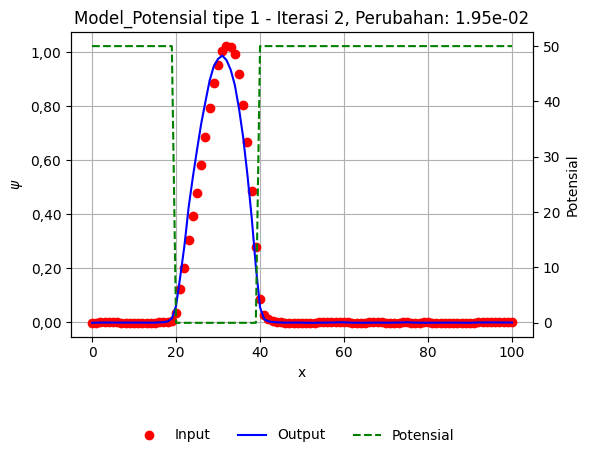

Iterasi 3, perubahan: 8.234780e-03
Iterasi 4, perubahan: 3.798744e-03
Iterasi 5, perubahan: 1.749058e-03
Iterasi 6, perubahan: 7.984718e-04
Iterasi 7, perubahan: 3.621993e-04
Iterasi 8, perubahan: 1.638037e-04
Iterasi 9, perubahan: 7.396634e-05
Iterasi 10, perubahan: 3.338917e-05
Iterasi 11, perubahan: 1.505008e-05
Iterasi 12, perubahan: 6.804280e-06
Iterasi 13, perubahan: 3.051827e-06
Iterasi 14, perubahan: 1.390027e-06
Iterasi 15, perubahan: 6.325218e-07
Iterasi 16, perubahan: 2.772834e-07
Iterasi 17, perubahan: 1.238206e-07
Iterasi 18, perubahan: 5.394640e-08


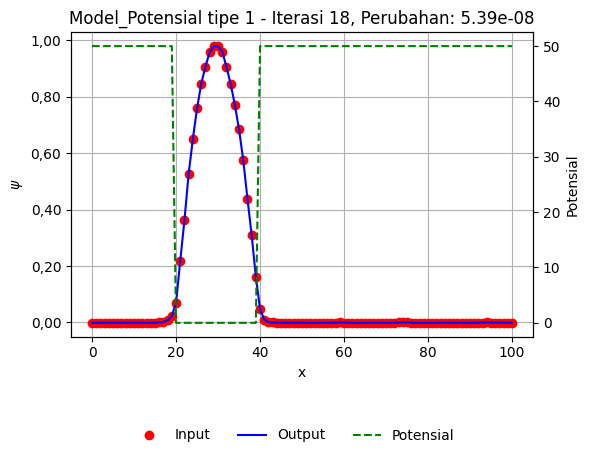

Konvergensi tercapai pada iterasi ke-18.
Iterasi 1, perubahan: 2.809523e-02
Iterasi 2, perubahan: 4.146912e-02


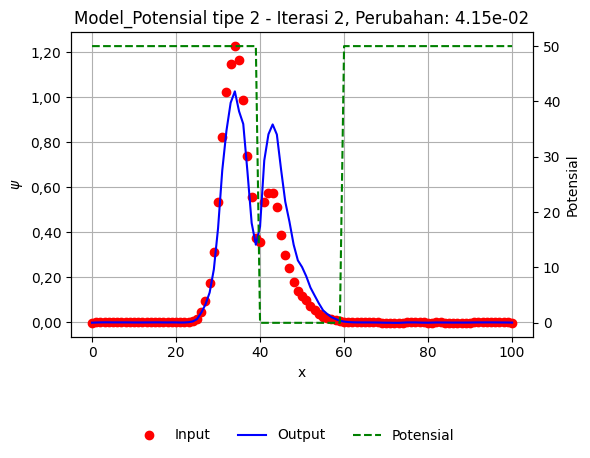

Iterasi 3, perubahan: 1.219723e-01
Iterasi 4, perubahan: 4.796848e-02
Iterasi 5, perubahan: 1.253609e-02
Iterasi 6, perubahan: 4.118352e-03
Iterasi 7, perubahan: 1.417465e-03
Iterasi 8, perubahan: 4.944304e-04
Iterasi 9, perubahan: 1.732131e-04
Iterasi 10, perubahan: 6.078069e-05
Iterasi 11, perubahan: 2.133364e-05
Iterasi 12, perubahan: 7.486025e-06
Iterasi 13, perubahan: 2.626285e-06
Iterasi 14, perubahan: 9.262811e-07
Iterasi 15, perubahan: 3.240714e-07
Iterasi 16, perubahan: 1.161489e-07
Iterasi 17, perubahan: 4.336060e-08


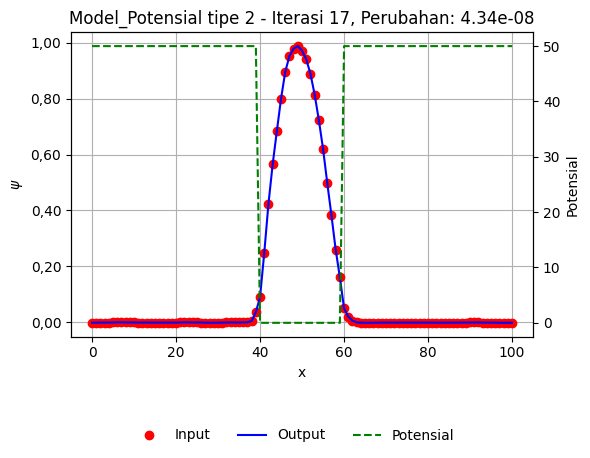

Konvergensi tercapai pada iterasi ke-17.


In [65]:
# Ambil channel 0 (psi) saja
psi_input = y_pred_all[0:1, :, 0:1]
# Untuk potensial 1

psi, hasil, hist = prediksi(psi_input, model, tol=1e-7, potensial_tipe=1)
psi2, hasil2, hist2 = prediksi(psi_input, model, tol=1e-7, potensial_tipe=2)

# Untuk data yang berbeda

In [74]:
import time

X_test_list, y_true_list, y_pred_list = [], [], []

model.eval()

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.no_grad():
    for X_batch, y_batch in test_loader3:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        X_test_list.append(X_batch.cpu())
        y_true_list.append(y_batch.cpu())
        y_pred_list.append(y_pred.cpu())

if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()
elapsed_time = end_time - start_time

X_test_all3 = torch.cat(X_test_list)
y_true_all3 = torch.cat(y_true_list)
y_pred_all3 = torch.cat(y_pred_list)

n_samples = y_true_all.shape[0]
print(f"Waktu inferensi total : {elapsed_time:.4f} detik")

Waktu inferensi total : 0.2918 detik


Iterasi 1, perubahan: 4.084064e-02
Iterasi 2, perubahan: 1.813885e-02


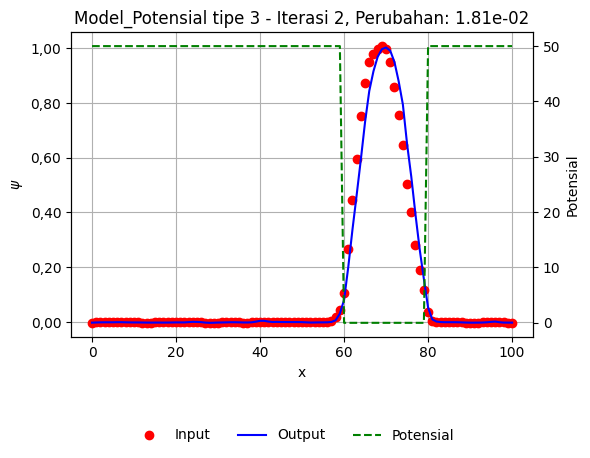

Iterasi 3, perubahan: 7.346279e-03
Iterasi 4, perubahan: 2.738562e-03
Iterasi 5, perubahan: 9.751553e-04
Iterasi 6, perubahan: 3.412595e-04
Iterasi 7, perubahan: 1.186922e-04
Iterasi 8, perubahan: 4.119816e-05
Iterasi 9, perubahan: 1.427688e-05
Iterasi 10, perubahan: 4.963276e-06
Iterasi 11, perubahan: 1.709873e-06
Iterasi 12, perubahan: 6.052134e-07
Iterasi 13, perubahan: 2.004888e-07
Iterasi 14, perubahan: 8.196445e-08


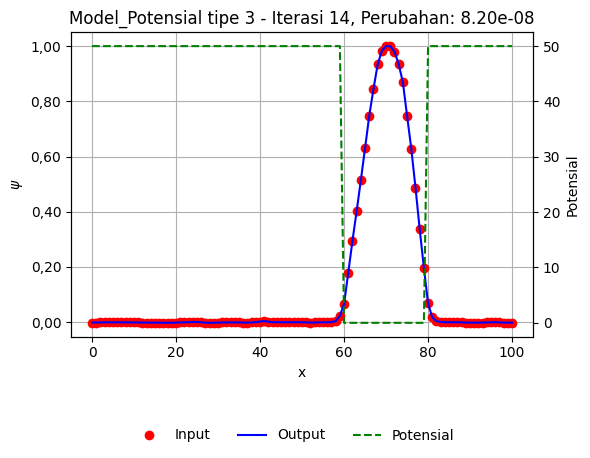

Konvergensi tercapai pada iterasi ke-14.


In [67]:
# Ambil channel 0 (psi) saja
psi_input3 = y_pred_all3[0:1, :, 0:1]
# Untuk potensial 1

psi3, hasil3, hist3 = prediksi(psi_input3, model, tol=1e-7, potensial_tipe=3)

In [77]:
import time

# Fungsi untuk iterasi dengan FDTD
def fdtd_iterasi(X, dx=0.1, L=10, dt=0.005, Nt=100000, tol=1e-8, potensial=3):
    Nx = int(L / dx)
    x = np.linspace(0, L, Nx + 1)
    dx2 = dx**2
    # Buat 3 tipe potensial
    v = np.zeros(Nx + 1)
    if potensial == 1:
        v[:20] = 50.0
        v[20:40] = 0.0
        v[40:] = 50.0
    elif potensial == 2:
        v[:40] = 50.0
        v[40:60] = 0.0
        v[60:] = 50.0
    elif potensial == 3:
        v[:60] = 50.0
        v[60:80] = 0.0
        v[80:] = 50.0
    else:
        raise ValueError(f"Tipe potensial {potensial} belum didefinisikan")

    # Normalisasi & ambil psi awal
    X_norm = normalisasi(X, dx=dx)
    psi = X_norm[0, :, 0].detach().cpu().numpy().copy()
    history = []
    # Koefisien FDTD
    a = (1 - 0.5 * dt * v) / (1 + 0.5 * dt * v)
    b = dt / (2 * dx2 * (1 + 0.5 * dt * v))

    # --- mulai timer ---
    start_time = time.perf_counter()

    for iterasi in range(1, Nt + 1):
        psi_new = np.zeros_like(psi)
        for i in range(1, Nx):
            psi_new[i] = a[i] * psi[i] + b[i] * (psi[i + 1] - 2 * psi[i] + psi[i - 1])
        psi_new[0] = psi_new[-1] = 0.0  # Syarat batas
        perubahan = np.linalg.norm(psi_new - psi)
        history.append(perubahan)
        # Cek konvergensi
        if perubahan < tol:
            # --- selesai timer (konvergen) ---
            end_time = time.perf_counter()
            elapsed_time = end_time - start_time
            print(f"Konvergensi tercapai pada iterasi ke-{iterasi}, perubahan:{perubahan:.2e}")
            print(f"Waktu komputasi FDTD    : {elapsed_time:.4f} detik")
            print(f"Waktu rata-rata/iterasi : {elapsed_time / iterasi * 1000:.4f} ms")
            # === Plot fungsi gelombang dan potensial ===
            fig, ax1 = plt.subplots(figsize=(6, 4))
            ax1.plot(x, psi, label='Input', color='blue')
            ax1.plot(x, psi_new, label='Output', color='red')
            ax1.set_xlabel('x')
            ax1.set_ylabel(r'$\psi(x)$', color='black')
            ax1.tick_params(axis='y')
            ax1.grid(True)
            ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))
            # Sumbu kanan untuk potensial
            ax2 = ax1.twinx()
            ax2.plot(x, v, '--', label='Potensial ', color='green')
            ax2.set_ylabel('$V(x)$')
            ax2.tick_params(axis='y')

            # Gabungkan legend dari kedua sumbu
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2, labels1 + labels2,
                       loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.15), frameon=False)
            plt.title(f'FDTD_Potensial {potensial} - Iterasi {iterasi}')
            plt.tight_layout()
            filename = f'fdtd_konvergen_pot{potensial}_iter{iterasi}.png'
            plt.savefig(filename, dpi=800)
            plt.show()
            plt.close()
            break
        # Update untuk iterasi berikutnya
        psi = psi_new.copy()
    else:
        # --- selesai timer (Nt tercapai tanpa konvergen) ---
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        print(f"Iterasi maksimum ({Nt}) tercapai tanpa konvergensi. Perubahan terakhir: {history[-1]:.2e}")
        print(f"Waktu komputasi FDTD    : {elapsed_time:.4f} detik")
        print(f"Waktu rata-rata/iterasi : {elapsed_time / Nt * 1000:.4f} ms")

    return psi, history

Konvergensi tercapai pada iterasi ke-2787, perubahan:9.95e-09
Waktu komputasi FDTD    : 0.5190 detik
Waktu rata-rata/iterasi : 0.1862 ms


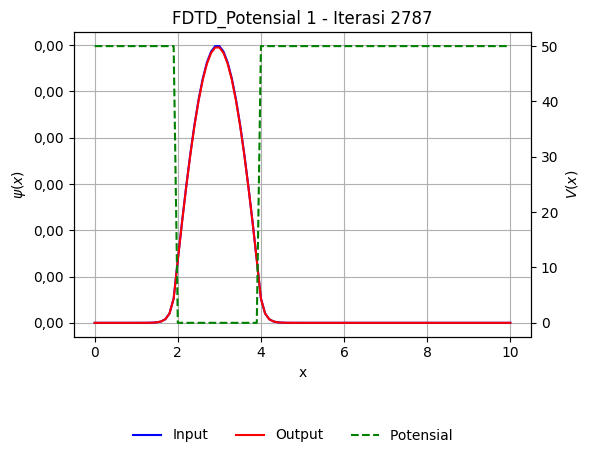

Konvergensi tercapai pada iterasi ke-2464, perubahan:9.96e-09
Waktu komputasi FDTD    : 0.3861 detik
Waktu rata-rata/iterasi : 0.1567 ms


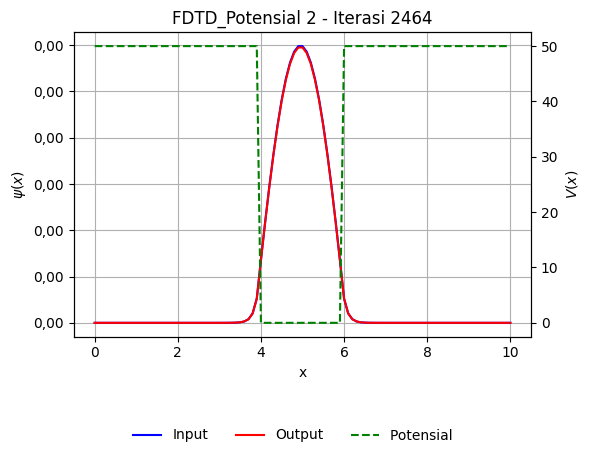

Konvergensi tercapai pada iterasi ke-2844, perubahan:9.96e-09
Waktu komputasi FDTD    : 0.4735 detik
Waktu rata-rata/iterasi : 0.1665 ms


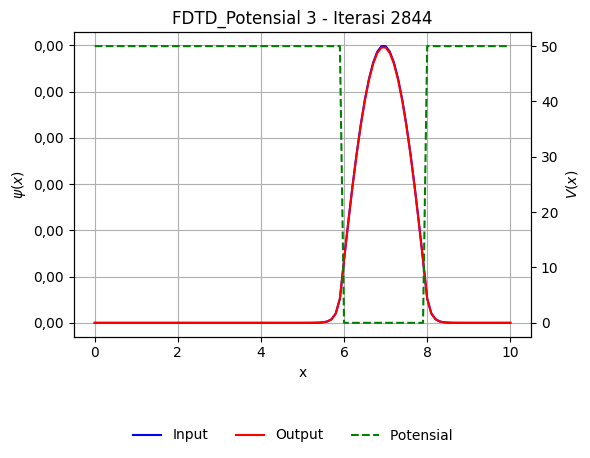

In [80]:
# Dengan potensial kotak 1


psi_fdtd, history = fdtd_iterasi(psi_input, potensial=1)
psi_fdtd2, history2 = fdtd_iterasi(psi_input, potensial=2)
psi_fdtd3, history3 = fdtd_iterasi(psi_input3, potensial=3)



In [81]:
def model_vs_fdtd(psi_model_list, psi_fdtd_list, dx=0.1, L=10):

    # Cek jumlah data
    if len(psi_model_list) != len(psi_fdtd_list):
        raise ValueError("Jumlah data model dan FDTD harus sama")

    print(f"Jumlah potensial yang dibandingkan: {len(psi_model_list)}")

    # ===================================================
    # Fungsi proses normalisasi, error, dan potensial
    # ===================================================
    def proses(psi_model, psi_fdtd, potensial):

        Nx = int(L / dx)
        x = np.linspace(0, L, Nx + 1)

        # Normalisasi L2
        norm_model = np.sqrt(np.sum(np.abs(psi_model)**2) * dx)
        norm_fdtd  = np.sqrt(np.sum(np.abs(psi_fdtd)**2) * dx)

        psi_model_norm = psi_model / norm_model
        psi_fdtd_norm  = psi_fdtd / norm_fdtd

        # ===================================================
        # Membuat potensial
        # ===================================================
        v = np.zeros(Nx + 1)

        if potensial == 1:

            v[:20] = 50.0
            v[20:40] = 0.0
            v[40:] = 50.0
        elif potensial == 2:
            v[:40] = 50.0
            v[40:60] = 0.0
            v[60:] = 50.0

        elif potensial == 3:
            v[:60] = 50.0
            v[60:80] = 0.0
            v[80:] = 50.0

        else:
            raise ValueError(
                f"Potensial {potensial} belum didefinisikan"
            )

        # ===================================================
        # Error relatif
        # ===================================================
        epsilon = 0.1
        error_rel = (
            100
            * np.abs(psi_fdtd_norm - psi_model_norm)
            / (np.abs(psi_fdtd_norm) + epsilon)
        )

        error_max = np.max(error_rel)

        print(
            f"Potensial {potensial} "
            f"Error maksimum = {error_max:.4f}%"
        )

        return x, psi_model_norm, psi_fdtd_norm, v, error_rel

    # ===================================================
    # Menyimpan error semua potensial
    # ===================================================
    all_errors = []

    # ===================================================
    # Loop semua potensial
    # ===================================================
    for i in range(len(psi_model_list)):

        psi_model = psi_model_list[i]
        psi_fdtd  = psi_fdtd_list[i]

        # Tensor -> numpy
        if isinstance(psi_model, torch.Tensor):
            psi_model = psi_model.detach().cpu().numpy().squeeze()

        if isinstance(psi_fdtd, torch.Tensor):
            psi_fdtd = psi_fdtd.detach().cpu().numpy().squeeze()

        # Proses
        x, psi_m, psi_f, v, err = proses(
            psi_model,
            psi_fdtd,
            potensial=i+1
        )

        all_errors.append((x, err, f"Potensial {i+1}"))

        # ===================================================
        # Plot fungsi gelombang
        # ===================================================
        fig, ax1 = plt.subplots(figsize=(7,4))

        ax1.plot(
            x,
            psi_m,
            'x',
            label="Model Transformer-2",
            color="red"
        )

        ax1.plot(
            x,
            psi_f,
            label="FDTD",
            color="blue"
        )

        ax1.set_xlabel("x")
        ax1.set_ylabel(r"$\psi(x)$")
        ax1.grid(True)
        ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))

        # Sumbu potensial
        ax2 = ax1.twinx()

        ax2.plot(
            x,
            v,
            "--",
            label="Potensial",
            color="green"
        )

        ax2.set_ylabel("$V(x)$")

        # Gabung legend
        line1, label1 = ax1.get_legend_handles_labels()
        line2, label2 = ax2.get_legend_handles_labels()

        fig.legend(
            line1 + line2,
            label1 + label2,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.05),
            ncol=3,
            frameon=False
        )

        plt.tight_layout()

        filename_wave = f"model_vs_fdtd_potensial_{i+1}.png"

        plt.savefig(
            filename_wave,
            dpi=800,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

    # ===================================================
    # Plot error gabungan
    # ===================================================
    plt.figure(figsize=(7,4))

    garis = ['--', '--', '--']
    warna = ['red', 'purple', 'orange']

    for i, (x, err, label) in enumerate(all_errors):

        if i >= len(garis):
            style, color = '-', None
        else:
            style, color = garis[i], warna[i]

        if style == 'o':
            plt.plot(
                x,
                err,
                linestyle="None",
                marker="o",
                markersize=4,
                label=label,
                color=color
            )
        else:
            plt.plot(
                x,
                err,
                linestyle=style,
                label=label,
                color=color
            )

    plt.xlabel("x")
    plt.ylabel("Error Relatif (%)")
    plt.grid(True)

    plt.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.2),
        ncol=3,
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(
        "gabungan_error_relatif.png",
        dpi=800,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [82]:
psi_model = hasil
psi_fdtd = psi_fdtd

psi_model2 = hasil2
psi_fdtd2 = psi_fdtd2

psi_model3 = hasil3
psi_fdtd3 = psi_fdtd3


psi_model_list = [psi_model, psi_model2, psi_model3]
psi_fdtd_list = [psi_fdtd, psi_fdtd2, psi_fdtd3]

Jumlah potensial yang dibandingkan: 3
Potensial 1 Error maksimum = 46.0385%


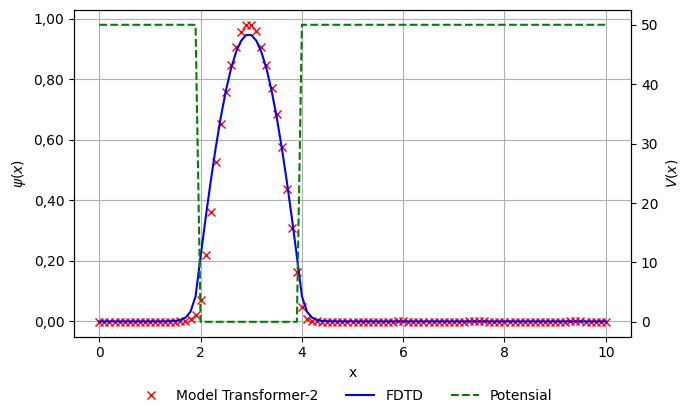

Potensial 2 Error maksimum = 39.6181%


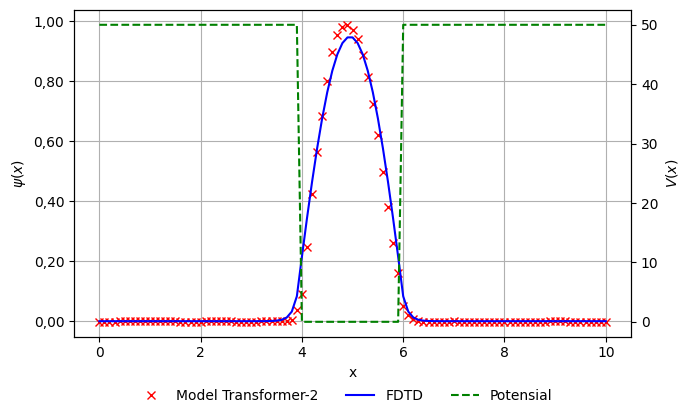

Potensial 3 Error maksimum = 47.5490%


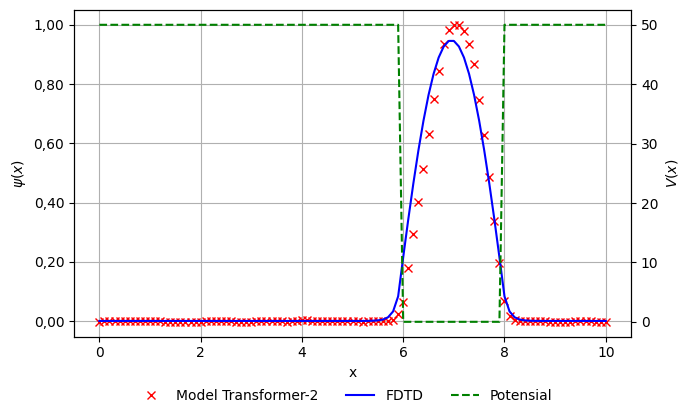

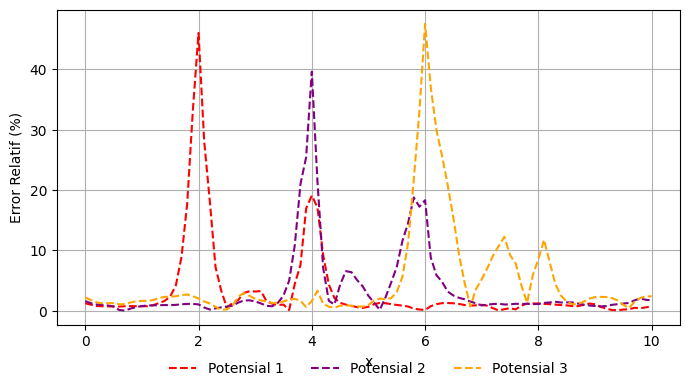

In [83]:
model_vs_fdtd(psi_model_list, psi_fdtd_list)

In [88]:
# Fungsi untuk menghitung energi keadaan dasar
def hitung_energi(psi, V, dx=0.1):
    Nx = len(psi)
    d2psi = np.zeros(Nx)
    d2psi[1:-1] = (psi[:-2] - 2 * psi[1:-1] + psi[2:]) / dx**2
    H_psi = -0.5 * d2psi + V * psi
    E = np.sum(psi * H_psi) * dx
    return E
    # Fungsi membuat bentuk potensial berdasarkan tipe
def buat_potensial(Nx):
    v = np.zeros(Nx + 1)
    for i in range(Nx + 1):
        v[i] = 50.0 if (i <= 20 or i >= 40) else 0.0
    return v

def normalisasi(psi, dx=0.1):
    return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)

# Parameter domain
dx = 0.1
Nx = 100
L = Nx * dx
x = np.linspace(0, L, Nx + 1)
print("="*50)
print("MENGHITUNG ENERGI UNTUK POTENSIAL 1")
print("="*50)
V1 = buat_potensial(Nx)
# Ambil dan normalisasi fungsi gelombang
psi_model = psi[0, :, 0].detach().cpu().numpy()
psi_fdtd = psi_fdtd
psi_model_norm = normalisasi(psi_model, dx)
psi_fdtd_norm = normalisasi(psi_fdtd, dx)
# Hitung energi
E_model = hitung_energi(psi_model_norm, V1, dx)
E_fdtd = hitung_energi(psi_fdtd_norm, V1, dx)
# Cetak hasil
print(f"Energi Model Transformer2   : {E_model:.6f}")
print(f"Energi FDTD                 : {E_fdtd:.6f}")
print(f"Error Relatif               : {abs(E_model - E_fdtd) / abs(E_fdtd) * 100:.2f}%")

MENGHITUNG ENERGI UNTUK POTENSIAL 1
Energi Model Transformer2   : 1.125679
Energi FDTD                 : 1.227590
Error Relatif               : 8.30%


In [89]:
# Fungsi untuk menghitung energi keadaan dasar
def hitung_energi(psi, V, dx=0.1):
    Nx = len(psi)
    d2psi = np.zeros(Nx)
    d2psi[1:-1] = (psi[:-2] - 2 * psi[1:-1] + psi[2:]) / dx**2
    H_psi = -0.5 * d2psi + V * psi
    E = np.sum(psi * H_psi) * dx
    return E
    # Fungsi membuat bentuk potensial berdasarkan tipe
def buat_potensial(Nx):
    v = np.zeros(Nx + 1)
    for i in range(Nx + 1):
        v[i] = 50.0 if (i <= 40 or i >= 60) else 0.0
    return v

def normalisasi(psi, dx=0.1):
    return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)

# Parameter domain
dx = 0.1
Nx = 100
L = Nx * dx
x = np.linspace(0, L, Nx + 1)
print("="*50)
print("MENGHITUNG ENERGI UNTUK POTENSIAL 1")
print("="*50)
V2 = buat_potensial(Nx)
# Ambil dan normalisasi fungsi gelombang
psi_model2 = psi2[0, :, 0].detach().cpu().numpy()
psi_fdtd2 = psi_fdtd2
psi_model_norm2 = normalisasi(psi_model2, dx)
psi_fdtd_norm2 = normalisasi(psi_fdtd2, dx)
# Hitung energi
E_model2 = hitung_energi(psi_model_norm2, V2, dx)
E_fdtd2 = hitung_energi(psi_fdtd_norm2, V2, dx)
# Cetak hasil
print(f"Energi Model Transformer2   : {E_model2:.6f}")
print(f"Energi FDTD                 : {E_fdtd2:.6f}")
print(f"Error Relatif               : {abs(E_model2 - E_fdtd2) / abs(E_fdtd2) * 100:.2f}%")

MENGHITUNG ENERGI UNTUK POTENSIAL 1
Energi Model Transformer2   : 1.139531
Energi FDTD                 : 1.227590
Error Relatif               : 7.17%


In [90]:
# Fungsi untuk menghitung energi keadaan dasar
def hitung_energi(psi, V, dx=0.1):
    Nx = len(psi)
    d2psi = np.zeros(Nx)
    d2psi[1:-1] = (psi[:-2] - 2 * psi[1:-1] + psi[2:]) / dx**2
    H_psi = -0.5 * d2psi + V * psi
    E = np.sum(psi * H_psi) * dx
    return E
    # Fungsi membuat bentuk potensial berdasarkan tipe
def buat_potensial(Nx):
    v = np.zeros(Nx + 1)
    for i in range(Nx + 1):
        v[i] = 50.0 if (i <= 60 or i >= 80) else 0.0
    return v

def normalisasi(psi, dx=0.1):
    return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)

# Parameter domain
dx = 0.1
Nx = 100
L = Nx * dx
x = np.linspace(0, L, Nx + 1)
print("="*50)
print("MENGHITUNG ENERGI UNTUK POTENSIAL 1")
print("="*50)
V3 = buat_potensial(Nx)
# Ambil dan normalisasi fungsi gelombang
psi_model3 = psi3[0, :, 0].detach().cpu().numpy()
psi_fdtd3 = psi_fdtd3
psi_model_norm3 = normalisasi(psi_model3, dx)
psi_fdtd_norm3 = normalisasi(psi_fdtd3, dx)
# Hitung energi
E_model3 = hitung_energi(psi_model_norm3, V3, dx)
E_fdtd3 = hitung_energi(psi_fdtd_norm3, V3, dx)
# Cetak hasil
print(f"Energi Model Transformer-3   : {E_model3:.6f}")
print(f"Energi FDTD                 : {E_fdtd3:.6f}")
print(f"Error Relatif               : {abs(E_model3 - E_fdtd3) / abs(E_fdtd3) * 100:.2f}%")

MENGHITUNG ENERGI UNTUK POTENSIAL 1
Energi Model Transformer-3   : 1.136129
Energi FDTD                 : 1.227590
Error Relatif               : 7.45%
